In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import sys
import os
import pprint
import tensorflow as tf
from tensorflow.keras.layers import TFSMLayer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve
from neuralnet.decorators import Reference
import csv
import json
import hgq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()

from neuralnet.datasets.ringer import RingerParquetDataset
from neuralnet.bins import VariableBin, AbsoluteVariableBin 
from neuralnet.workflows.ringer.training import PreprocessingPipeline

['/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/claraalbinopacheco/Library/Python/3.13/lib/python/site-packages', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet', '/Users/claraalbinopacheco/neuralnet']


ModuleNotFoundError: No module named 'neuralnet.datasets'

In [58]:
dataset_dir = "mc21_isabela_qt_2sigma_restriction"

In [59]:
ET_COL = "TrigEMClusterContainer.et"
ETA_COL = "TrigEMClusterContainer.eta"
DATA_TABLE = "electron_ringer"
RINGS_COL = "TrigEMClusterContainer.ringsE"
KFOLD_TABLE = "standard_binning_kfold"
LABEL_COL = "label"
FOLD_COL = "kfold"

In [60]:
pid_list = ['Very Loose', 'Loose', 'Medium', 'Tight']

table_data = {
            "et": [],
            "eta": [],
            "working_point": [],
            "target_signal_efficiency": [],
            "signal_efficiency": [],
            "background_efficiency": [],
            "threshold": []
        }

# vloose -> tight
target_tpr = [0.9982, 0.9980, 0.9976, 0.9958]

integrated_analysis = {
    'labels': np.array([]),
    'predictions': np.array([])
}

In [ ]:
def draw_roc_curve(fpr, tpr, thresholds, et, eta):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color='green', linewidth=2, label='17x3')
    for i, value in enumerate(target_tpr):
        idx = np.argmin(np.abs(tpr - value))
        table_data["et"].append(et)
        table_data["eta"].append(eta)
        table_data["working_point"].append(pid_list[i])
        table_data["target_signal_efficiency"].append(f'{value:.2%}')
        table_data["signal_efficiency"].append(f'{tpr[idx]:.4%}')
        table_data["background_efficiency"].append(f'{fpr[idx]:.4%}')
        table_data["threshold"].append(f'{thresholds[idx]:.4f}')

        # Operating point
        ax.scatter(fpr[idx], tpr[idx],
                s=120, zorder=5, edgecolors='black', color='green',
                label=f'@ {value:.4f} signal efficiency: (FR = {fpr[idx]:.4f})')

        ax.axhline(y=tpr[idx], color='green', linestyle='--', alpha=0.5)
        ax.axvline(x=fpr[idx], color='green', linestyle='--', alpha=0.5)
    
    ax.set_title(f'et{et}_eta{eta}')
    ax.set_xlabel('FR', fontsize=13)
    ax.set_ylabel('PD', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plots_dir = 'plots_roc_curve'
    if not os.path.exists(plots_dir):
        os.mkdir(plots_dir)
    plt.savefig(f'{plots_dir}/roc_et{et}_eta{eta}.png', dpi=150)
    print(f"Plot saved: roc_et{et}_eta{eta}.png")

    table_filename = "op_points_regions_no_sigmoid.csv"
    df = pd.DataFrame(table_data)
    df.to_csv(table_filename, index=False, encoding='utf-8')

6997/6997 ━━━━━━━━━━━━━━━━━━━━ 2s 293us/step
model: model_0022.keras, et: 3, eta: 0
Plot saved: roc_et3_eta0.png
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 2s 305us/step
model: model_0044.keras, et: 3, eta: 1
Plot saved: roc_et3_eta1.png
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 375us/step
model: model_0063.keras, et: 3, eta: 2
Plot saved: roc_et3_eta2.png
7013/7013 ━━━━━━━━━━━━━━━━━━━━ 2s 290us/step
model: model_0091.keras, et: 3, eta: 3
Plot saved: roc_et3_eta3.png
587/587 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step
model: model_0122.keras, et: 3, eta: 4
Plot saved: roc_et3_eta4.png
7383/7383 ━━━━━━━━━━━━━━━━━━━━ 2s 286us/step
model: model_0132.keras, et: 4, eta: 0
Plot saved: roc_et4_eta0.png
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 2s 293us/step
model: model_0151.keras, et: 4, eta: 1
Plot saved: roc_et4_eta1.png
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step
model: model_0196.keras, et: 4, eta: 2
Plot saved: roc_et4_eta2.png
6221/6221 ━━━━━━━━━━━━━━━━━━━━ 2s 290us/step
model: model_0214.keras, et: 4, eta: 3
Plot saved: ro

/var/folders/3k/dxc55h1544l7j0zv3xcz1y6h0000gn/T/ipykernel_1094/2220440857.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 7))


2569/2569 ━━━━━━━━━━━━━━━━━━━━ 1s 329us/step
model: model_0545.keras, et: 7, eta: 1
Plot saved: roc_et7_eta1.png
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
model: model_0564.keras, et: 7, eta: 2
Plot saved: roc_et7_eta2.png
2245/2245 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step
model: model_0596.keras, et: 7, eta: 3
Plot saved: roc_et7_eta3.png
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
model: model_0615.keras, et: 7, eta: 4
Plot saved: roc_et7_eta4.png


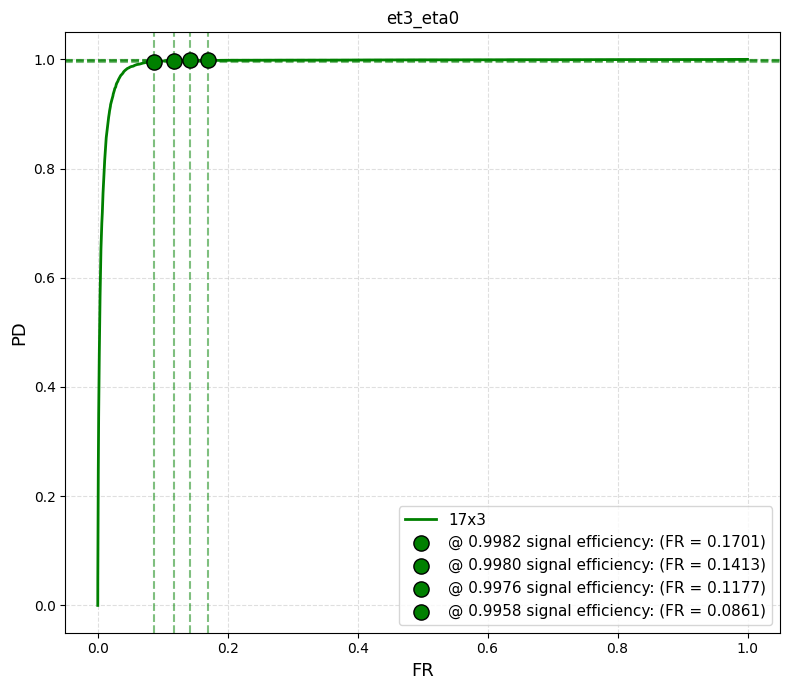

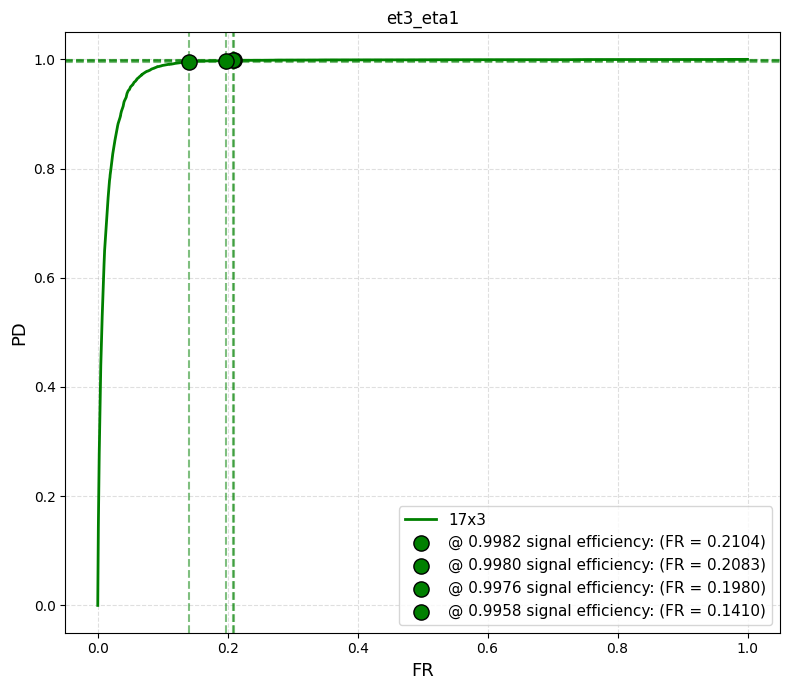

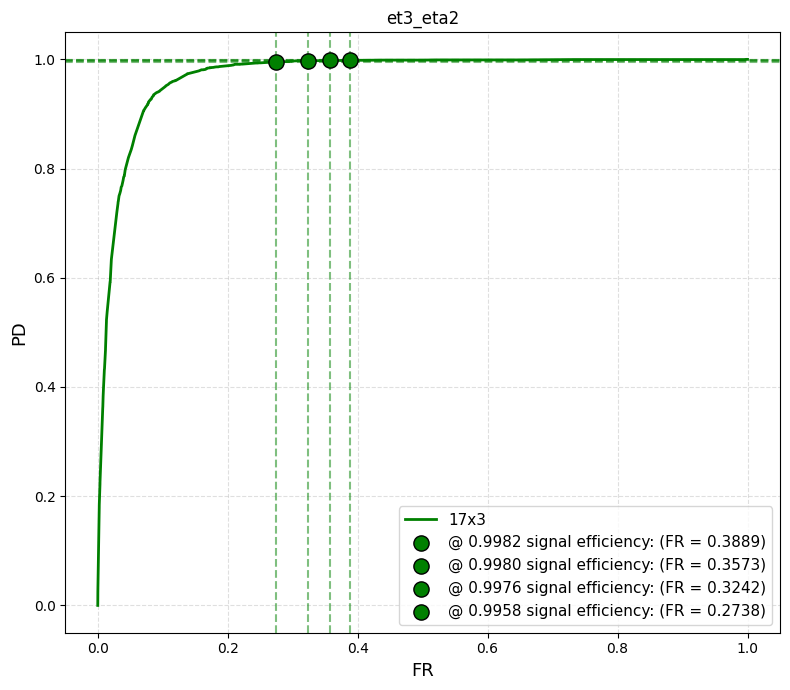

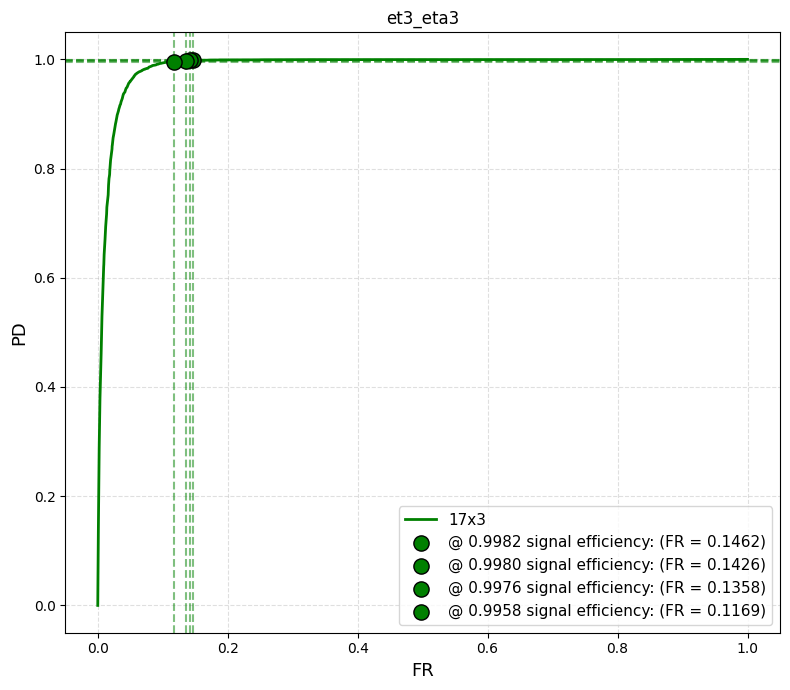

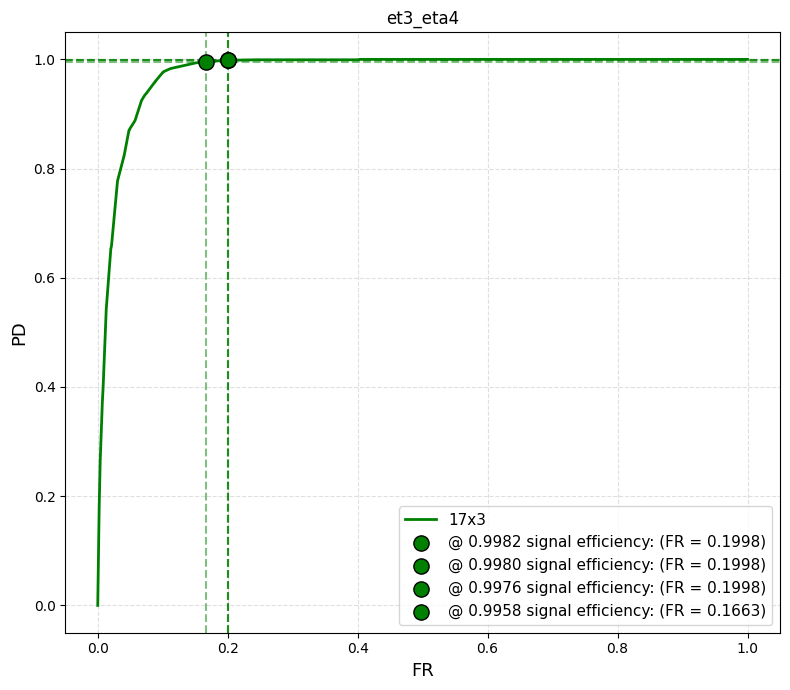

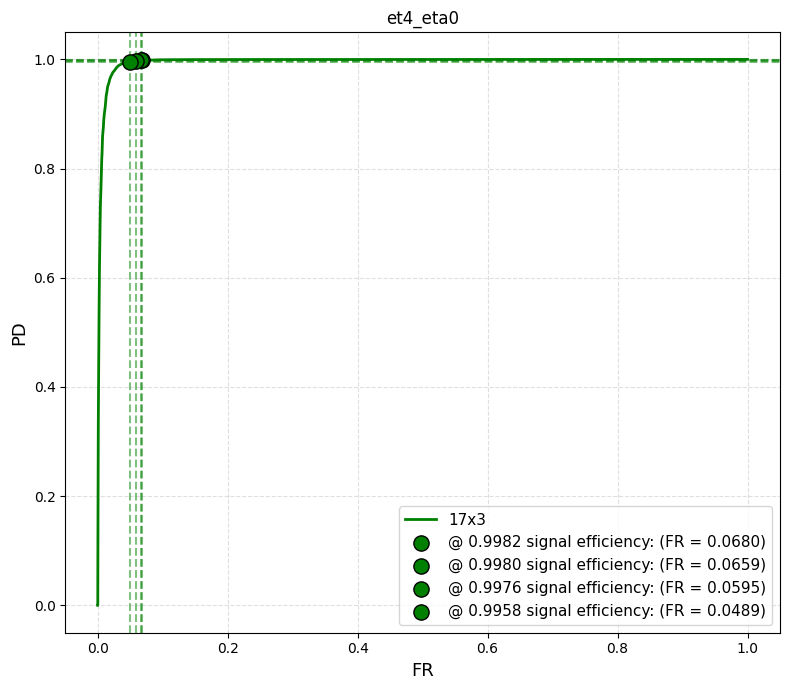

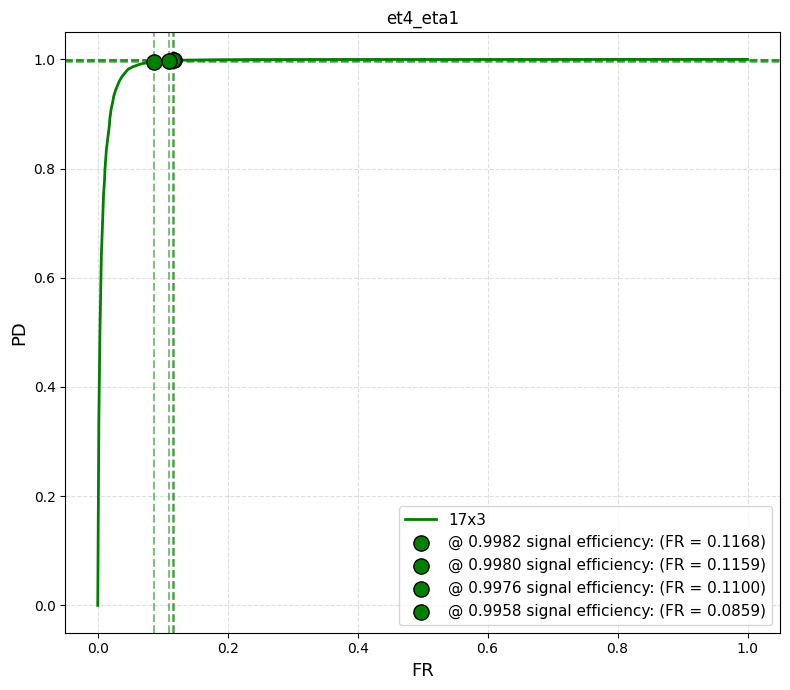

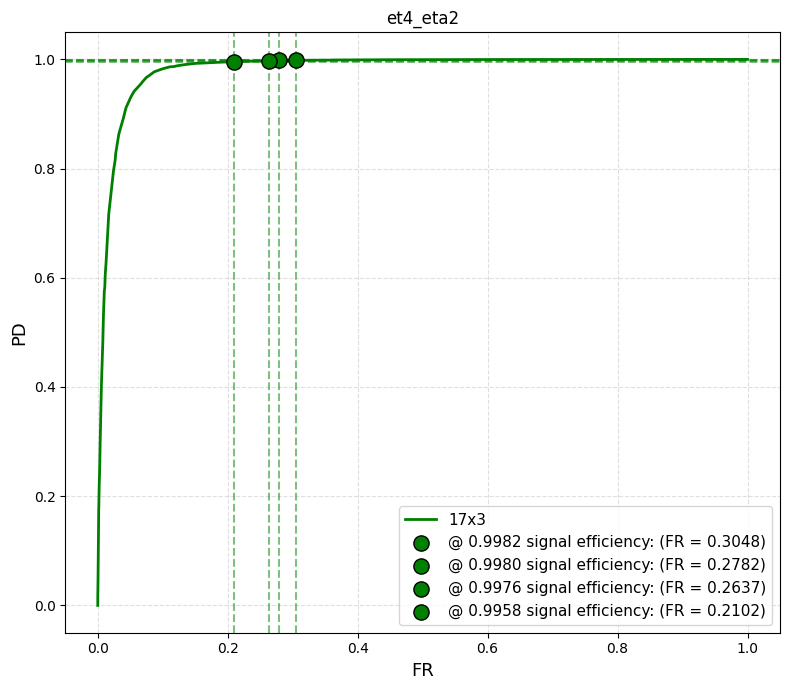

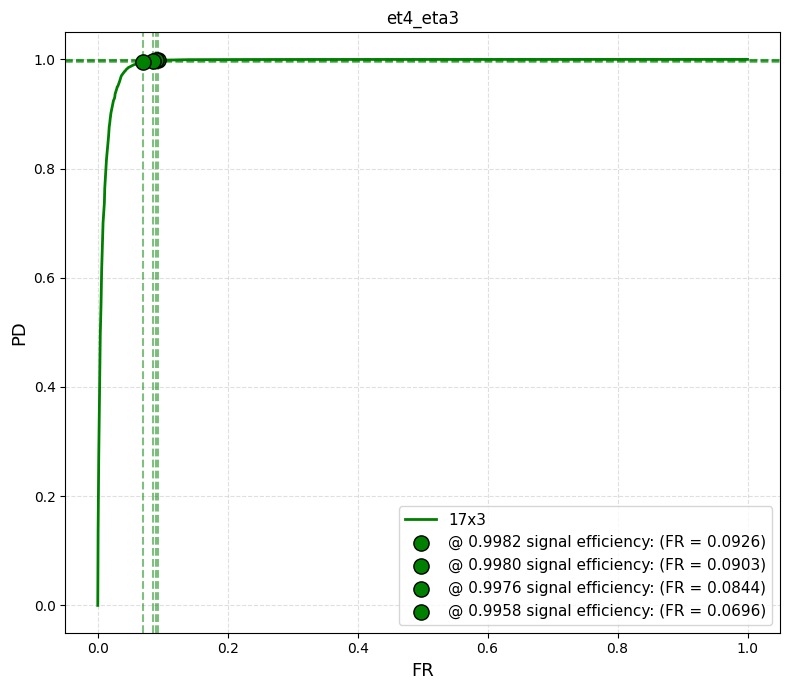

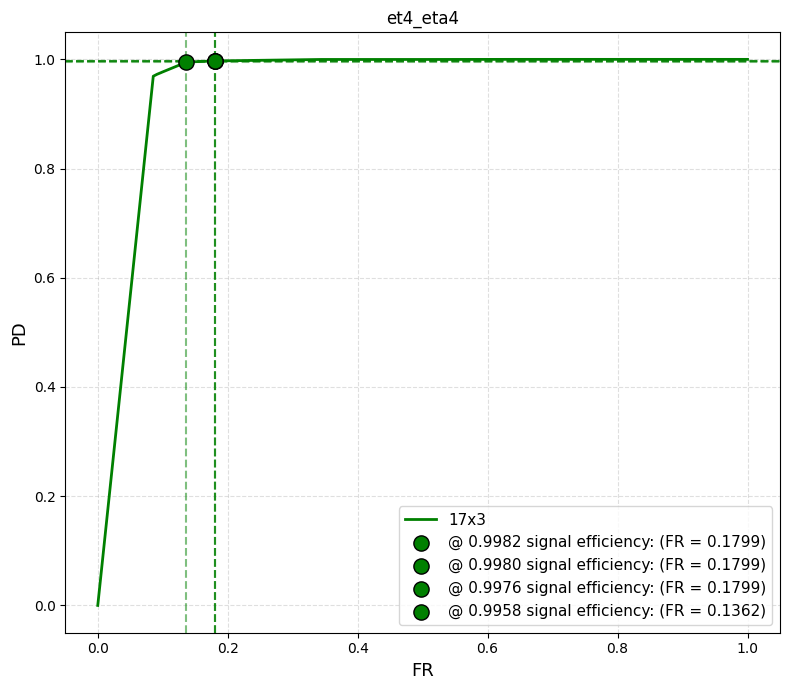

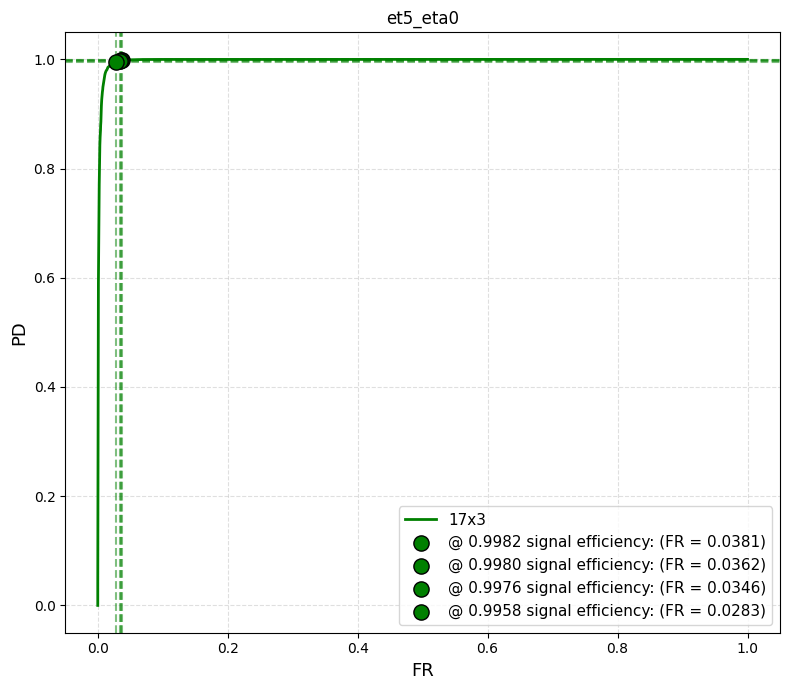

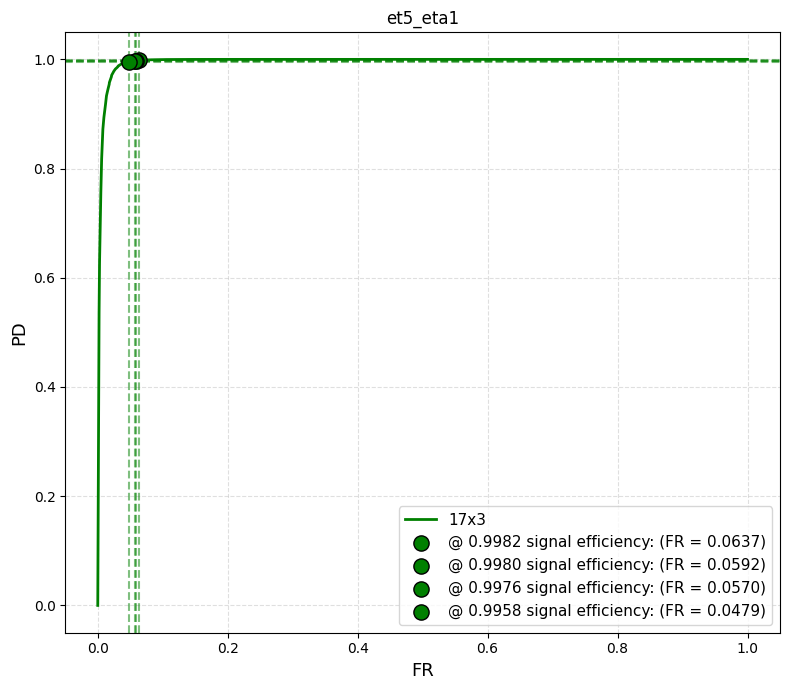

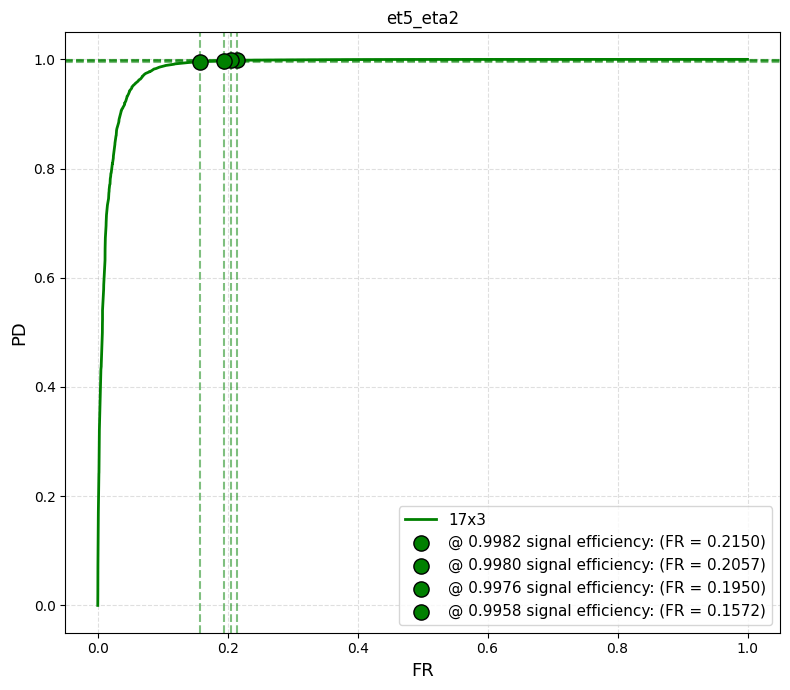

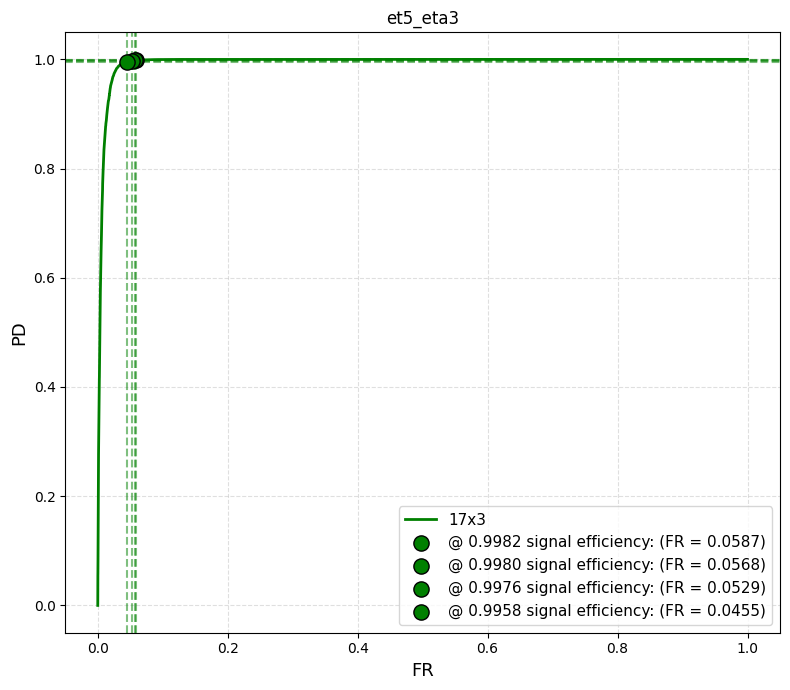

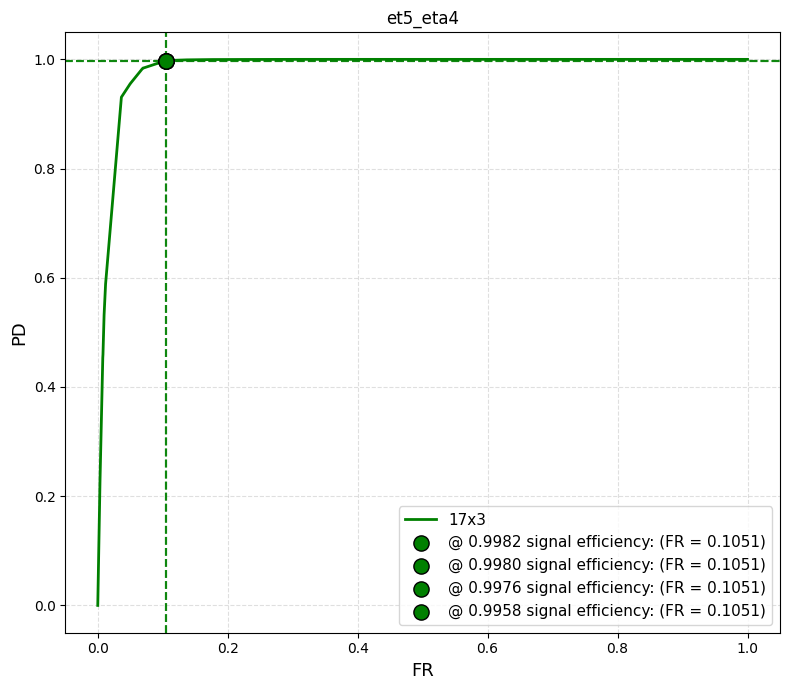

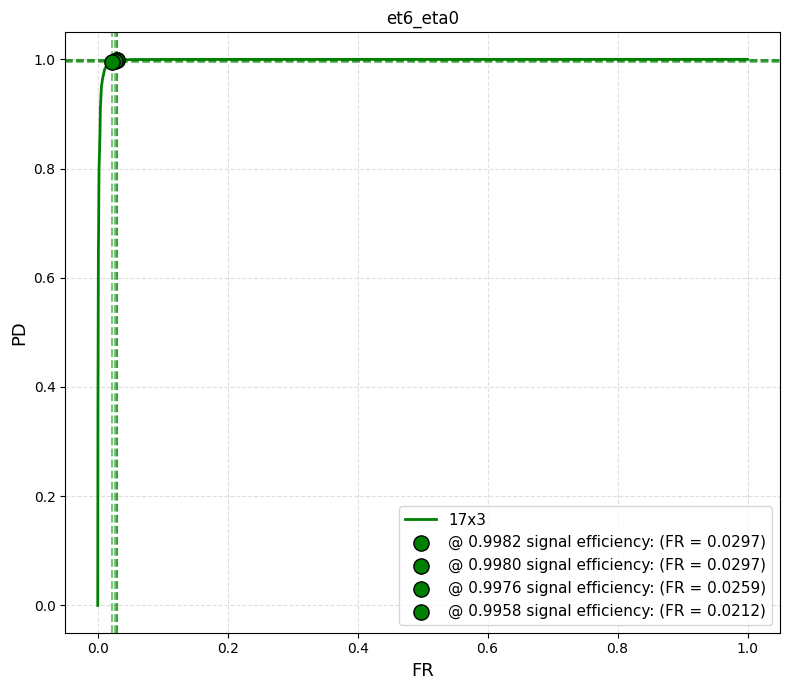

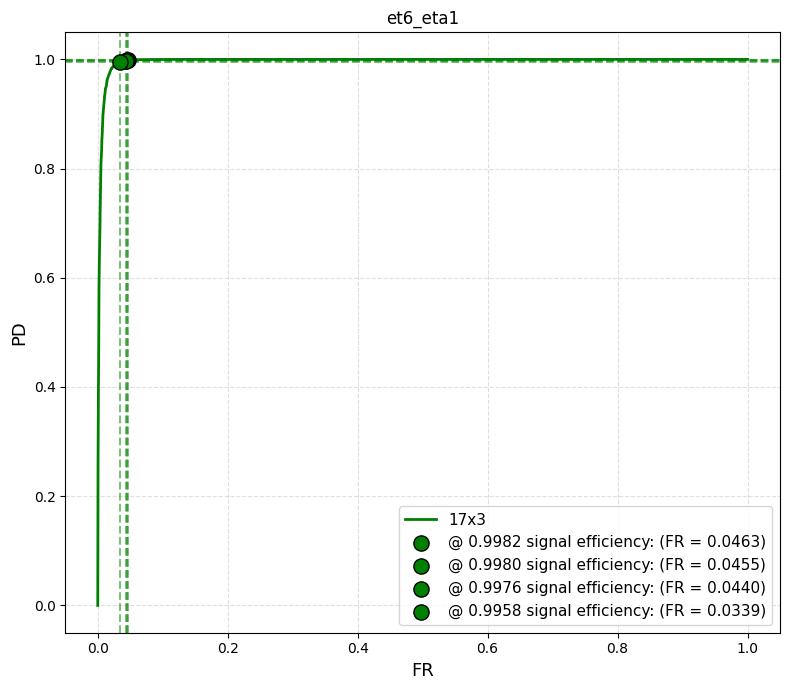

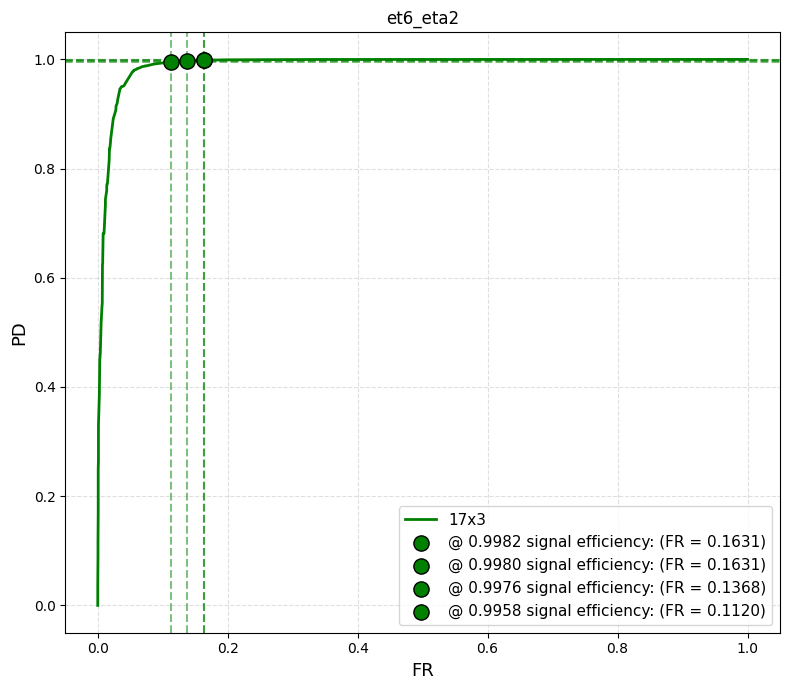

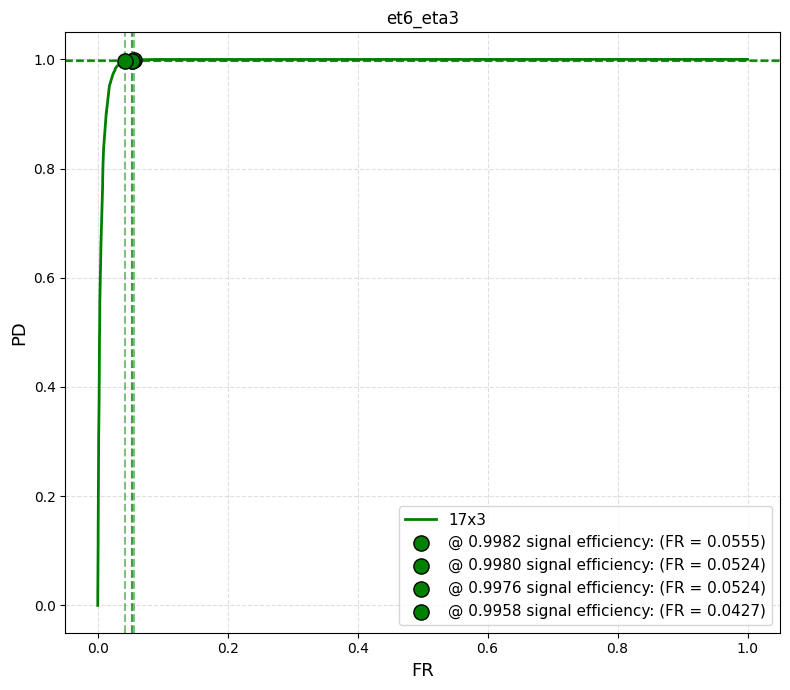

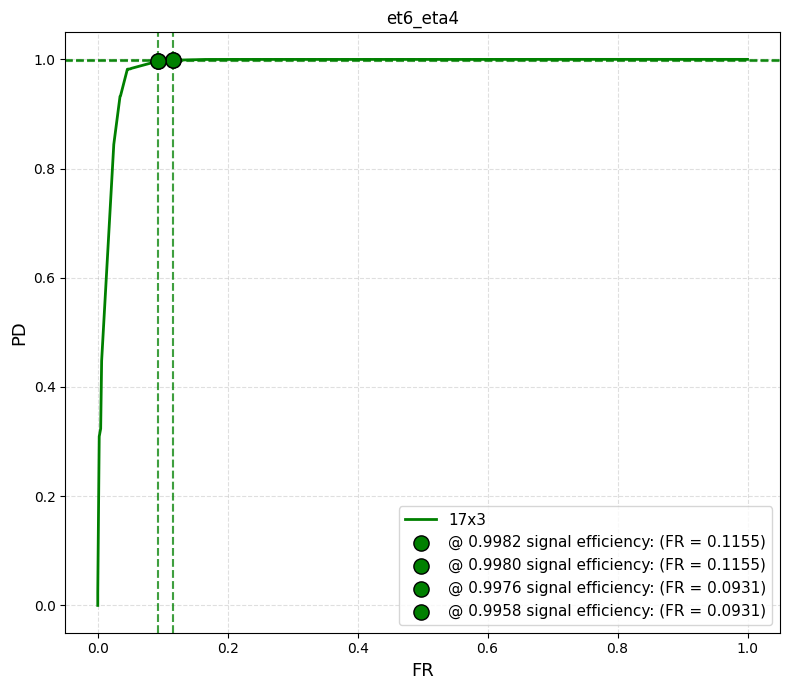

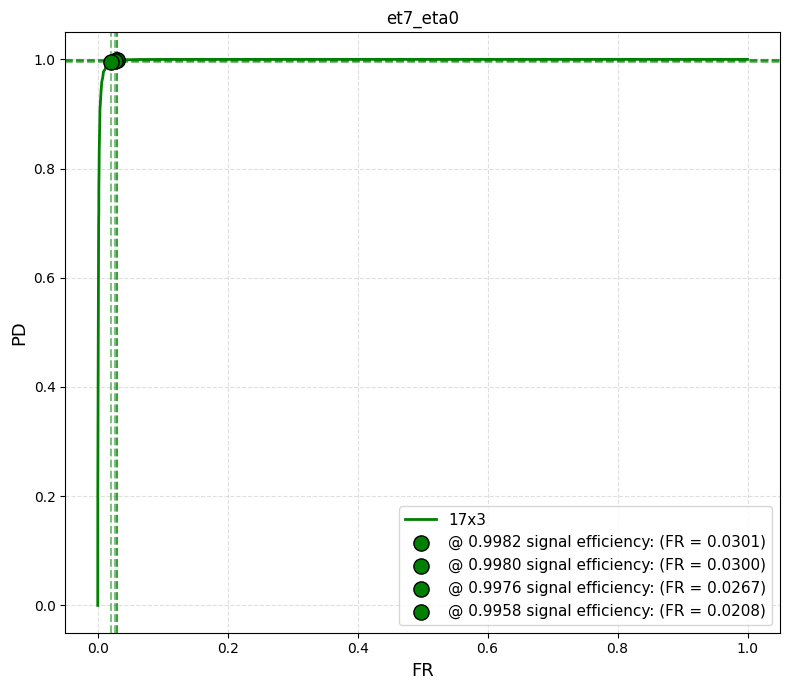

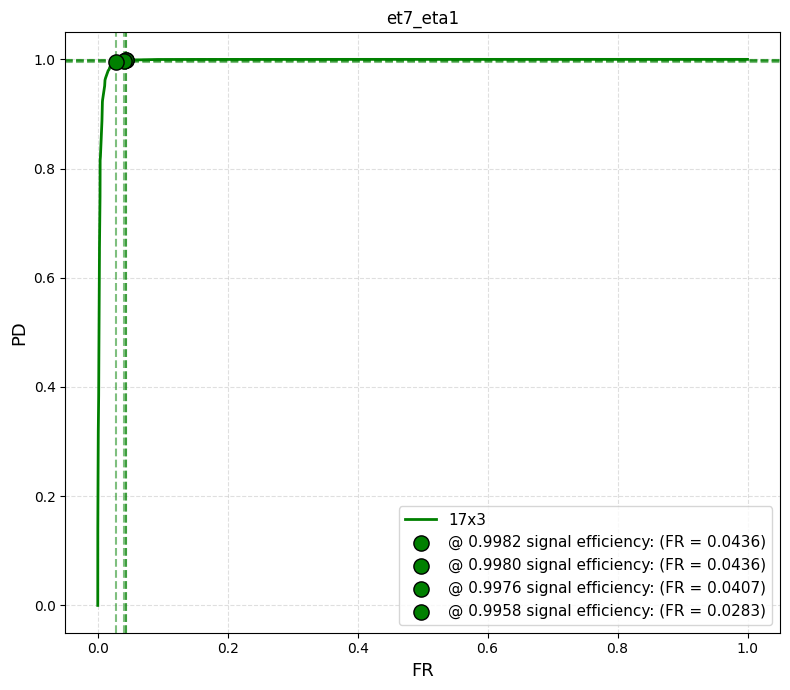

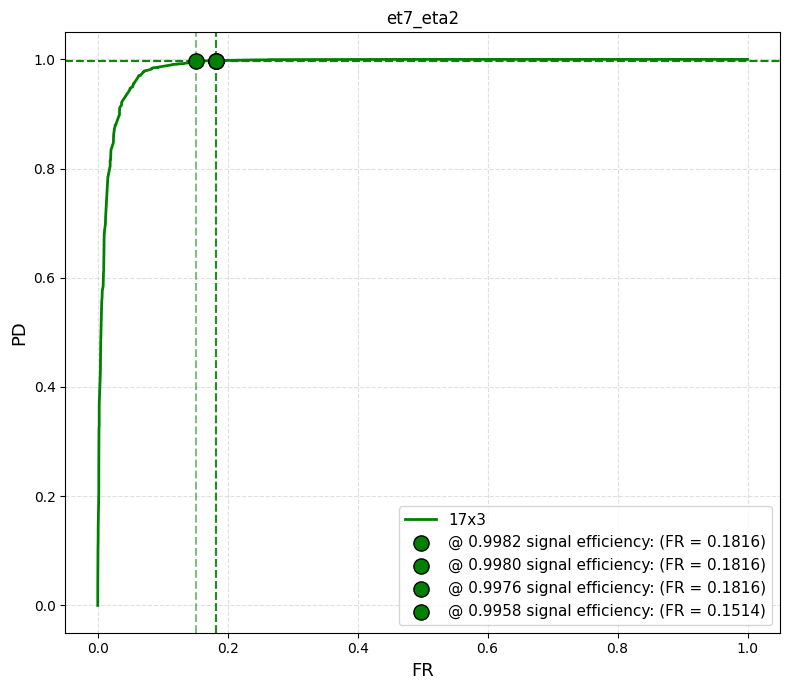

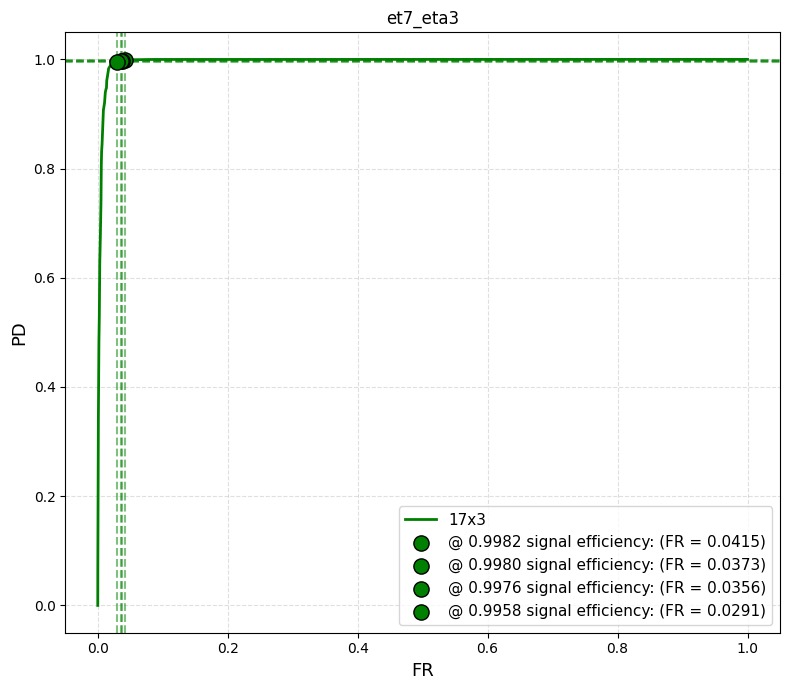

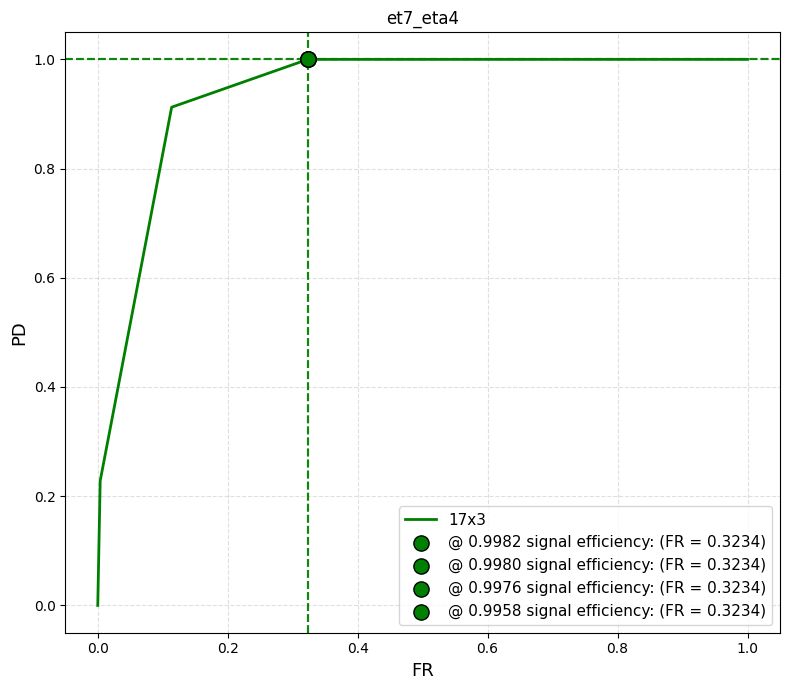

In [62]:
best_models = pl.read_parquet('ringer_v0_qat/best_models.parquet')
et = 2
index = 0
for row in best_models.iter_rows(named=True):
    eta = index % 5
    if eta == 0: 
        et += 1
    bins = [
        AbsoluteVariableBin(var_name=ETA_COL, low=row["eta_bin_lower"], high=row["eta_bin_upper"], closed="left"),
        VariableBin(var_name=ET_COL, low=row["et_bin_lower"],  high=row["et_bin_upper"],  closed="left"),
    ]

    object_type = RingerParquetDataset(dataset_dir=dataset_dir, 
                                       data_table=DATA_TABLE, 
                                       rings_col=RINGS_COL, 
                                       kfold_table=KFOLD_TABLE, 
                                       et_bin=bins[1], eta_bin=bins[0])
    
    model_path = f"ringer_v0_qat/{row["model"]}"
    linear_model = tf.keras.models.load_model(model_path, compile=False)

    preprocessing_pipeline = PreprocessingPipeline.from_job_params(
        rings_col=RINGS_COL,
        ring_fraction=2,          
        norm_strategy='l1',       
    )

    test_df = object_type.test_df()
    test_df_processed = test_df.pipe(preprocessing_pipeline, passthrough=True).collect()
    features = test_df_processed.select(preprocessing_pipeline.output_cols).to_numpy()

    predictions = linear_model.predict(features).flatten()
    labels = test_df_processed[LABEL_COL].to_numpy()

    integrated_analysis['labels'] = np.append(integrated_analysis['labels'], labels)
    integrated_analysis['predictions'] = np.append(integrated_analysis['predictions'], predictions)

    fpr, tpr, thresholds = roc_curve(labels, predictions)
    print(f'model: {row["model"]}, et: {et}, eta: {eta}')
    draw_roc_curve(fpr, tpr, thresholds, et, eta)
    index += 1



all models, et: 0, eta: 0
Plot saved: roc_et0_eta0.png


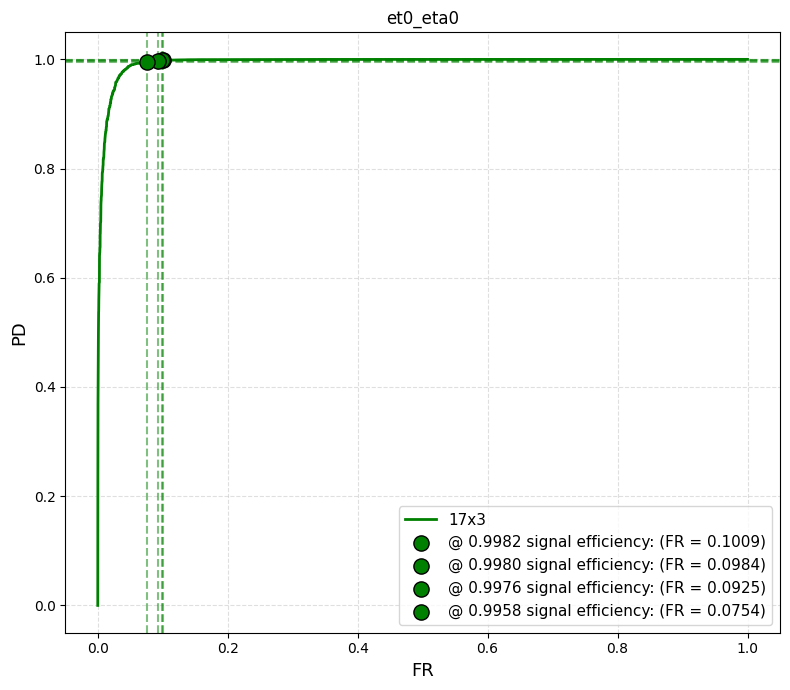

In [64]:
et = 0
eta = 0
fpr, tpr, thresholds = roc_curve(integrated_analysis['labels'], integrated_analysis['predictions'])
print(f'all models, et: {et}, eta: {eta}')
draw_roc_curve(fpr, tpr, thresholds, et, eta)